**Extracting the Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_file = "/content/drive/MyDrive/AI-ML/CNN_Task/plantVillageDataset.zip"
extract_path = "/content/plantVillageDataset"

# Unzip
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

Importing Libraries

In [ ]:
# Core Libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import warnings
warnings.filterwarnings('ignore')

# Deep Learning (Keras / TensorFlow)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Metrics
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully ")

TensorFlow version: 2.20.0
All libraries imported successfully 


Selecting Tomato Only classes

In [ ]:
DATASET_PATH = "/content/plantVillageDataset/PlantVillage"

#  Filter only Tomato folders
all_folders = os.listdir(DATASET_PATH)
tomato_folders = [f for f in all_folders if f.lower().startswith("tomato")]

print(f"Total folders in dataset : {len(all_folders)}")
print(f"Tomato folders found     : {len(tomato_folders)}")
print("\n Tomato Classes:")

for i, folder in enumerate(sorted(tomato_folders)):
    count = len(os.listdir(os.path.join(DATASET_PATH, folder)))
    print(f"  {i+1:>2}. {folder:<50} ----- {count} images")

Total folders in dataset : 15
Tomato folders found     : 10

 Tomato Classes:
   1. Tomato_Bacterial_spot                              ----- 2127 images
   2. Tomato_Early_blight                                ----- 1000 images
   3. Tomato_Late_blight                                 ----- 1909 images
   4. Tomato_Leaf_Mold                                   ----- 952 images
   5. Tomato_Septoria_leaf_spot                          ----- 1771 images
   6. Tomato_Spider_mites_Two_spotted_spider_mite        ----- 1676 images
   7. Tomato__Target_Spot                                ----- 1404 images
   8. Tomato__Tomato_YellowLeaf__Curl_Virus              ----- 3209 images
   9. Tomato__Tomato_mosaic_virus                        ----- 373 images
  10. Tomato_healthy                                     ----- 1591 images


Splitting dataset for train test and validation


In [ ]:
import shutil
import random

#  Destination folders
TOMATO_PATH      = "/content/tomato_dataset/train"
VAL_PATH         = "/content/tomato_dataset/val"
TEST_PATH        = "/content/tomato_dataset/test"

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

random.seed(42)

base = "/content/tomato_dataset"
if not os.path.exists(base):
    print("Splitting dataset into train / val / test ...\n")

    for cls in tomato_folders:
        src_cls = os.path.join(DATASET_PATH, cls)
        all_images = os.listdir(src_cls)
        random.shuffle(all_images)

        total      = len(all_images)
        train_end  = int(total * TRAIN_RATIO)
        val_end    = train_end + int(total * VAL_RATIO)

        splits = {
            TOMATO_PATH : all_images[:train_end],
            VAL_PATH    : all_images[train_end:val_end],
            TEST_PATH   : all_images[val_end:]
        }

        for dest_path, img_list in splits.items():
            cls_dest = os.path.join(dest_path, cls)
            os.makedirs(cls_dest, exist_ok=True)
            for img in img_list:
                shutil.copy(
                    os.path.join(src_cls, img),
                    os.path.join(cls_dest, img)
                )

        # print summary per class
        print(f"  {cls:<50}")
        print(f"    Train: {len(splits[TOMATO_PATH])} | "
              f"Val: {len(splits[VAL_PATH])} | "
              f"Test: {len(splits[TEST_PATH])}")

    print("\n Dataset split complete!")

else:
    print("Split already exists ")

#  Final count
train_count = sum(len(os.listdir(os.path.join(TOMATO_PATH, c)))
                  for c in os.listdir(TOMATO_PATH))
val_count   = sum(len(os.listdir(os.path.join(VAL_PATH, c)))
                  for c in os.listdir(VAL_PATH))
test_count  = sum(len(os.listdir(os.path.join(TEST_PATH, c)))
                  for c in os.listdir(TEST_PATH))

print(f"\n{'Split':<12} {'Images':>8}")
print("-" * 22)
print(f"{'Train':<12} {train_count:>8}")
print(f"{'Validation':<12} {val_count:>8}")
print(f"{'Test':<12} {test_count:>8}")
print(f"{'TOTAL':<12} {train_count+val_count+test_count:>8}")

Splitting dataset into train / val / test ...

  Tomato_healthy                                    
    Train: 1113 | Val: 238 | Test: 240
  Tomato_Leaf_Mold                                  
    Train: 666 | Val: 142 | Test: 144
  Tomato__Tomato_mosaic_virus                       
    Train: 261 | Val: 55 | Test: 57
  Tomato__Tomato_YellowLeaf__Curl_Virus             
    Train: 2246 | Val: 481 | Test: 482
  Tomato__Target_Spot                               
    Train: 982 | Val: 210 | Test: 212
  Tomato_Septoria_leaf_spot                         
    Train: 1239 | Val: 265 | Test: 267
  Tomato_Late_blight                                
    Train: 1336 | Val: 286 | Test: 287
  Tomato_Early_blight                               
    Train: 700 | Val: 150 | Test: 150
  Tomato_Bacterial_spot                             
    Train: 1488 | Val: 319 | Test: 320
  Tomato_Spider_mites_Two_spotted_spider_mite       
    Train: 1173 | Val: 251 | Test: 252

 Dataset split complete!

Split       

Visualizations of the tomato class

Class                                                   Images
---------------------------------------------------------------
Tomato_Bacterial_spot                                     1488
Tomato_Early_blight                                        700
Tomato_Late_blight                                        1336
Tomato_Leaf_Mold                                           666
Tomato_Septoria_leaf_spot                                 1239
Tomato_Spider_mites_Two_spotted_spider_mite               1173
Tomato__Target_Spot                                        982
Tomato__Tomato_YellowLeaf__Curl_Virus                     2246
Tomato__Tomato_mosaic_virus                                261
Tomato_healthy                                            1113
---------------------------------------------------------------
TOTAL                                                    11204


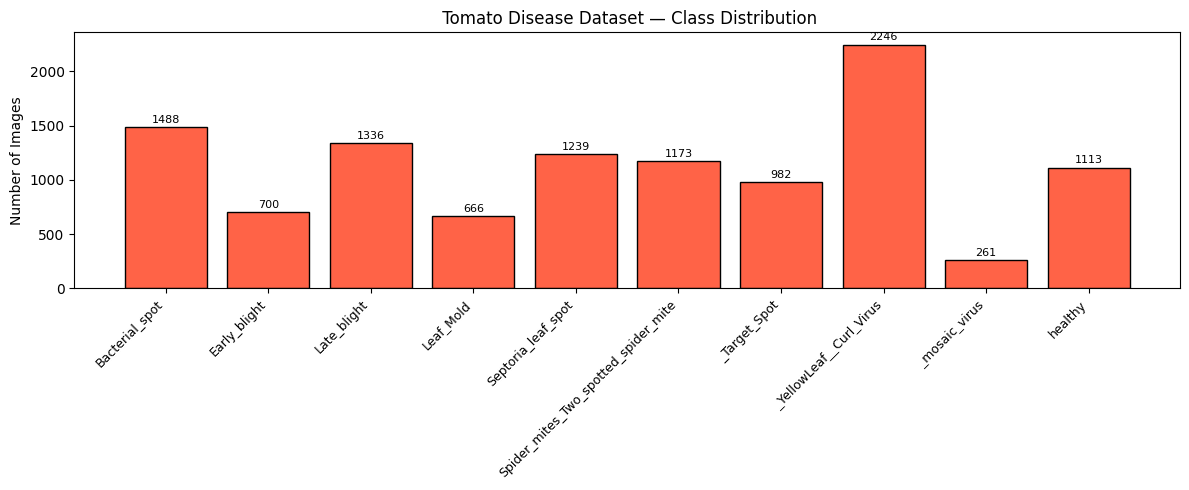

In [ ]:
# Count images per class
class_names = sorted(os.listdir(TOMATO_PATH))
class_counts = []

for cls in class_names:
    count = len(os.listdir(os.path.join(TOMATO_PATH, cls)))
    class_counts.append(count)

total_images = sum(class_counts)

print(f"{'Class':<55} {'Images':>6}")
print("-" * 63)
for cls, count in zip(class_names, class_counts):
    print(f"{cls:<55} {count:>6}")
print("-" * 63)
print(f"{'TOTAL':<55} {total_images:>6}")

# Bar Chart
plt.figure(figsize=(12, 5))
bars = plt.bar(range(len(class_names)), class_counts, color='tomato', edgecolor='black')
plt.xticks(range(len(class_names)),
           [c.replace("Tomato_", "").replace("Tomato__", "") for c in class_names],
           rotation=45, ha='right', fontsize=9)
plt.ylabel("Number of Images")
plt.title(" Tomato Disease Dataset — Class Distribution")
plt.tight_layout()

# Add count labels on top of bars
for bar, count in zip(bars, class_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(count), ha='center', va='bottom', fontsize=8)

plt.savefig("class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

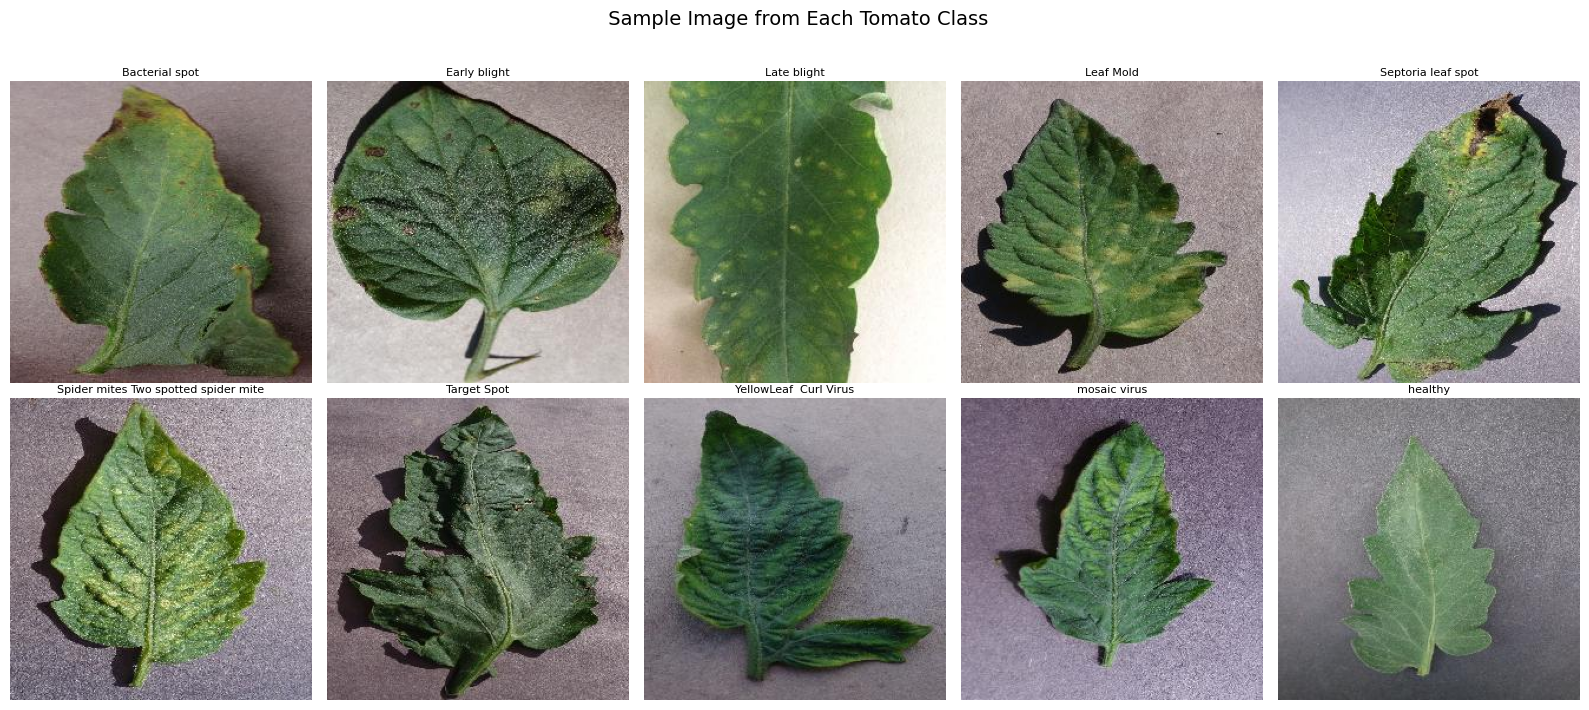

In [ ]:
# Show 1 sample image per class
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

for i, cls in enumerate(class_names):
    cls_path = os.path.join(TOMATO_PATH, cls)
    img_file = os.listdir(cls_path)[0]
    img = mpimg.imread(os.path.join(cls_path, img_file))
    axes[i].imshow(img)
    axes[i].axis('off')
    # Clean up label for display
    label = cls.replace("Tomato__", "").replace("Tomato_", "").replace("_", " ")
    axes[i].set_title(label, fontsize=8, pad=4)

plt.suptitle(" Sample Image from Each Tomato Class", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150, bbox_inches='tight')
plt.show()

Data Augmentation

In [ ]:
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32


train_datagen = ImageDataGenerator(
    rescale            = 1./255,
    rotation_range     = 20,
    width_shift_range  = 0.2,
    height_shift_range = 0.2,
    shear_range        = 0.2,
    zoom_range         = 0.2,
    horizontal_flip    = True,
    fill_mode          = 'nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
#  Generators
train_generator = train_datagen.flow_from_directory(
    TOMATO_PATH,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = True,
    seed        = 42
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_PATH,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_PATH,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False
)

Found 11204 images belonging to 10 classes.
Found 2397 images belonging to 10 classes.
Found 2410 images belonging to 10 classes.


In [ ]:
NUM_CLASSES = len(train_generator.class_indices)
print(f"Train      : {train_generator.samples} images")
print(f"Validation : {val_generator.samples} images")
print(f"Test       : {test_generator.samples} images")
print(f"Classes    : {NUM_CLASSES}")

Train      : 11204 images
Validation : 2397 images
Test       : 2410 images
Classes    : 10


Handeling Data imbalance using class weight


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = train_generator.classes
classes = np.unique(labels)

weights = compute_class_weight('balanced', classes=classes, y=labels)

# Map class index - class name - weight
class_weight_dict = {
    cls_name: weights[idx]
    for cls_name, idx in train_generator.class_indices.items()
}

print(class_weight_dict)

{'Tomato_Bacterial_spot': np.float64(0.7529569892473118), 'Tomato_Early_blight': np.float64(1.6005714285714285), 'Tomato_Late_blight': np.float64(0.838622754491018), 'Tomato_Leaf_Mold': np.float64(1.6822822822822823), 'Tomato_Septoria_leaf_spot': np.float64(0.9042776432606942), 'Tomato_Spider_mites_Two_spotted_spider_mite': np.float64(0.955157715260017), 'Tomato__Target_Spot': np.float64(1.1409368635437882), 'Tomato__Tomato_YellowLeaf__Curl_Virus': np.float64(0.49884238646482637), 'Tomato__Tomato_mosaic_virus': np.float64(4.29272030651341), 'Tomato_healthy': np.float64(1.006648697214735)}


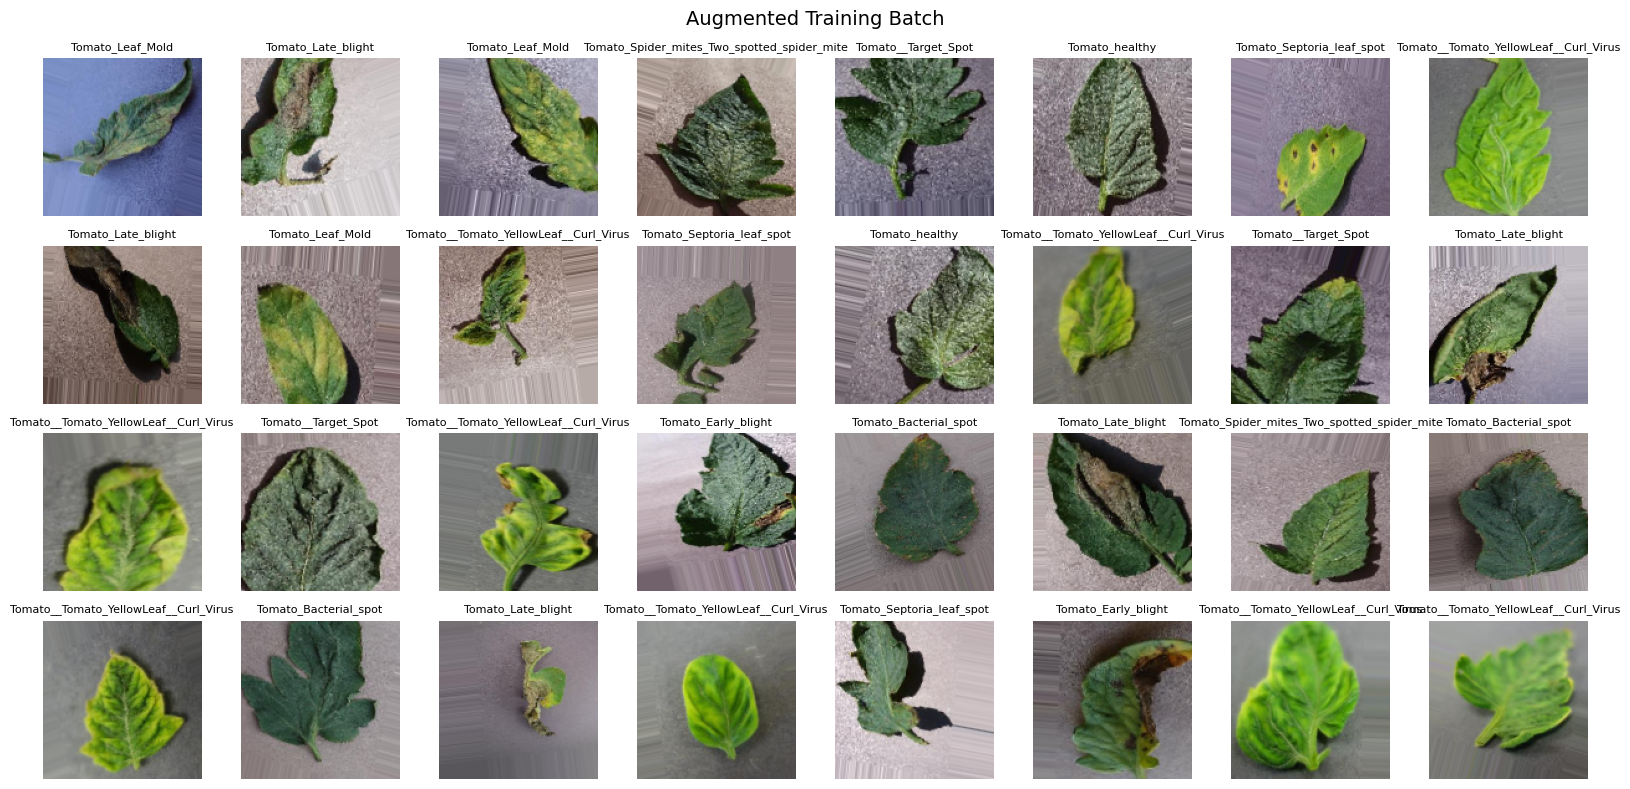

In [ ]:
import matplotlib.pyplot as plt

# Get one batch (already augmented!)
images, labels = next(train_generator)

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

class_names = list(train_generator.class_indices.keys())

for i in range(len(axes)):
    axes[i].imshow(images[i])

    # Get class label
    label_idx = labels[i].argmax()
    axes[i].set_title(class_names[label_idx], fontsize=8)

    axes[i].axis('off')

plt.suptitle("Augmented Training Batch", fontsize=14)
plt.tight_layout()
plt.show()

**Baseline Model**

In [ ]:
from tensorflow.keras import Input

def build_baseline_model(num_classes, input_shape=(128, 128, 3)):
    model = models.Sequential([

        Input(shape=input_shape),

        #  Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        #  Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        #  Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        #  Flatten
        layers.Flatten(),

        #  3 Fully Connected Layers
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64,  activation='relu'),

        #  Output Layer
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

#  Build and compile
baseline_model = build_baseline_model(NUM_CLASSES)

baseline_model.compile(
    optimizer = 'adam',
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,914 (32.52 MB)

 Trainable params: 8,523,914 (32.52 MB)

 Non-trainable params: 0 (0.00 B)

**Baseline Model Training**

In [ ]:
import time
from tensorflow.keras.callbacks import ModelCheckpoint

# Checkpoint
checkpoint = ModelCheckpoint(
    "best_baseline_CNN.h5",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

#  Callbacks
early_stop = EarlyStopping(
    monitor   = 'val_loss',
    patience  = 5,
    restore_best_weights = True,
    verbose   = 1
)

# learning rate config
reduce_lr = ReduceLROnPlateau(
    monitor  = 'val_loss',
    factor   = 0.5,
    patience = 3,
    verbose  = 1
)


In [ ]:
start_time = time.time()

baseline_history = baseline_model.fit(
    train_generator,
    validation_data = val_generator,
    epochs          = 25,
    class_weight    = class_weight_dict,
    callbacks       = [early_stop, reduce_lr, checkpoint],
    verbose         = 1
)

baseline_time = time.time() - start_time

print(f"Total training time: {baseline_time/60:.2f} minutes")

Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.3628 - loss: 1.7645
Epoch 1: val_loss improved from None to 0.92362, saving model to best_baseline_CNN.h5



Epoch 1: finished saving model to best_baseline_CNN.h5
351/351 ━━━━━━━━━━━━━━━━━━━━ 87s 231ms/step - accuracy: 0.5172 - loss: 1.3614 - val_accuracy: 0.6792 - val_loss: 0.9236 - learning_rate: 0.0010
Epoch 2/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.7393 - loss: 0.7393
Epoch 2: val_loss did not improve from 0.92362
351/351 ━━━━━━━━━━━━━━━━━━━━ 75s 213ms/step - accuracy: 0.7608 - loss: 0.6778 - val_accuracy: 0.6875 - val_loss: 1.1019 - learning_rate: 0.0010
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.8016 - loss: 0.5492
Epoch 3: val_loss improved from 0.92362 to 0.90220, saving model to best_baseline_CNN.h5



Epoch 3: finished saving model to best_baseline_CNN.h5
351/351 ━━━━━━━━━━━━━━━━━━━━ 64s 183ms/step - accuracy: 0.8155 - loss: 0.5178 - val_accuracy: 0.7359 - val_loss: 0.9022 - learning_rate: 0.0010
Epoch 4/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.8435 - loss: 0.4501
Epoch 4: val_loss improved from 0.90220 to 0.73510, saving model to best_baseline_CNN.h5



Epoch 4: finished saving model to best_baseline_CNN.h5
351/351 ━━━━━━━━━━━━━━━━━━━━ 83s 234ms/step - accuracy: 0.8359 - loss: 0.4675 - val_accuracy: 0.7797 - val_loss: 0.7351 - learning_rate: 0.0010
Epoch 5/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.8637 - loss: 0.3847
Epoch 5: val_loss did not improve from 0.73510
351/351 ━━━━━━━━━━━━━━━━━━━━ 84s 238ms/step - accuracy: 0.8650 - loss: 0.3837 - val_accuracy: 0.7347 - val_loss: 0.8686 - learning_rate: 0.0010
Epoch 6/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.8911 - loss: 0.3134
Epoch 6: val_loss improved from 0.73510 to 0.65261, saving model to best_baseline_CNN.h5



Epoch 6: finished saving model to best_baseline_CNN.h5
351/351 ━━━━━━━━━━━━━━━━━━━━ 62s 177ms/step - accuracy: 0.8899 - loss: 0.3171 - val_accuracy: 0.8131 - val_loss: 0.6526 - learning_rate: 0.0010
Epoch 7/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.8934 - loss: 0.3100
Epoch 7: val_loss improved from 0.65261 to 0.46353, saving model to best_baseline_CNN.h5



Epoch 7: finished saving model to best_baseline_CNN.h5
351/351 ━━━━━━━━━━━━━━━━━━━━ 63s 179ms/step - accuracy: 0.8932 - loss: 0.3003 - val_accuracy: 0.8569 - val_loss: 0.4635 - learning_rate: 0.0010
Epoch 8/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9066 - loss: 0.2563
Epoch 8: val_loss did not improve from 0.46353
351/351 ━━━━━━━━━━━━━━━━━━━━ 61s 175ms/step - accuracy: 0.9017 - loss: 0.2675 - val_accuracy: 0.8319 - val_loss: 0.5731 - learning_rate: 0.0010
Epoch 9/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9183 - loss: 0.2412
Epoch 9: val_loss did not improve from 0.46353
351/351 ━━━━━━━━━━━━━━━━━━━━ 64s 182ms/step - accuracy: 0.9148 - loss: 0.2502 - val_accuracy: 0.8473 - val_loss: 0.4807 - learning_rate: 0.0010
Epoch 10/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9205 - loss: 0.2270
Epoch 10: val_loss improved from 0.46353 to 0.31380, saving model to best_baseline_CNN.h5



Epoch 10: finished saving model to best_baseline_CNN.h5
351/351 ━━━━━━━━━━━━━━━━━━━━ 61s 173ms/step - accuracy: 0.9217 - loss: 0.2232 - val_accuracy: 0.9032 - val_loss: 0.3138 - learning_rate: 0.0010
Epoch 11/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9189 - loss: 0.2376
Epoch 11: val_loss did not improve from 0.31380
351/351 ━━━━━━━━━━━━━━━━━━━━ 64s 182ms/step - accuracy: 0.9193 - loss: 0.2342 - val_accuracy: 0.8419 - val_loss: 0.5375 - learning_rate: 0.0010
Epoch 12/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9301 - loss: 0.1962
Epoch 12: val_loss did not improve from 0.31380
351/351 ━━━━━━━━━━━━━━━━━━━━ 60s 172ms/step - accuracy: 0.9240 - loss: 0.2114 - val_accuracy: 0.8586 - val_loss: 0.5513 - learning_rate: 0.0010
Epoch 13/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9226 - loss: 0.2149
Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 13: val_loss did not improve from 0.31380
351/351 ━━━━━━━━━━━━━━

**Learning Curves**

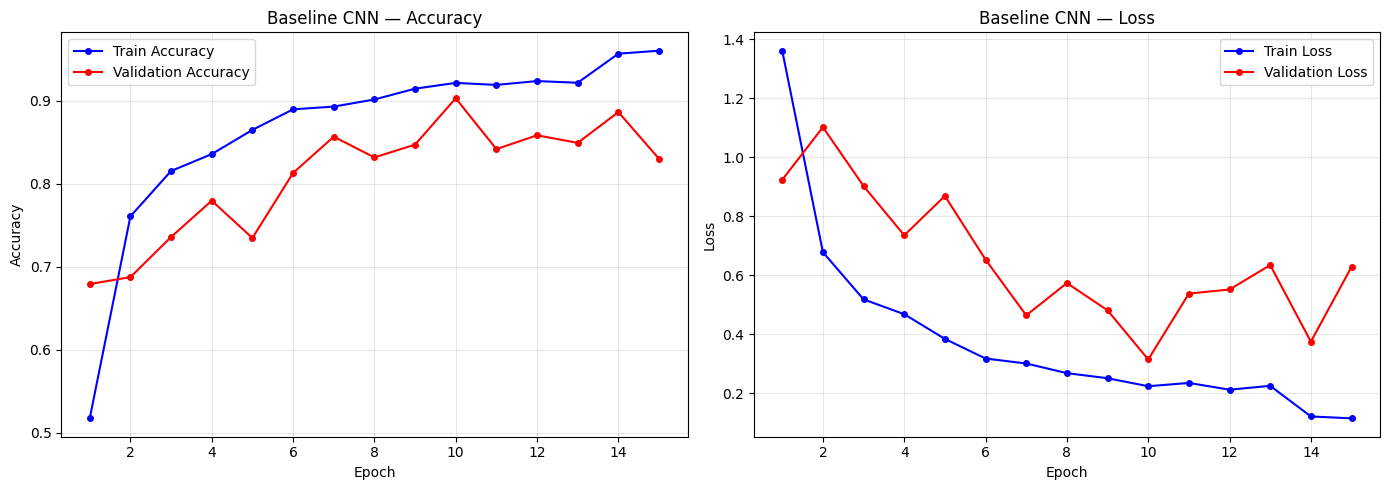

In [ ]:
def plot_history(history, model_name="Baseline CNN"):
    acc     = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss    = history.history['loss']
    val_loss= history.history['val_loss']
    epochs  = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    #  Accuracy
    ax1.plot(epochs, acc,     'b-o', label='Train Accuracy',      markersize=4)
    ax1.plot(epochs, val_acc, 'r-o', label='Validation Accuracy', markersize=4)
    ax1.set_title(f'{model_name} — Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    #  Loss
    ax2.plot(epochs, loss,     'b-o', label='Train Loss',      markersize=4)
    ax2.plot(epochs, val_loss, 'r-o', label='Validation Loss', markersize=4)
    ax2.set_title(f'{model_name} — Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{model_name.replace(' ', '_')}_curves.png",
                dpi=150, bbox_inches='tight')
    plt.show()

plot_history(baseline_history, "Baseline CNN")

**Evaluation on test set**

In [ ]:
print("Evaluating Baseline CNN on Test Set...\n")
test_loss, test_acc = baseline_model.evaluate(test_generator, verbose=1)
print(f"\nBaseline CNN - Test Accuracy : {test_acc*100:.2f}%")
print(f"Baseline CNN - Test Loss     : {test_loss:.4f}")

Evaluating Baseline CNN on Test Set...

76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.8967 - loss: 0.3274

Baseline CNN - Test Accuracy : 89.67%
Baseline CNN - Test Loss     : 0.3274


**Evaluation Metrics**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

#  Get predictions
test_generator.reset()
y_pred_probs = baseline_model.predict(test_generator, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_generator.classes

#  Class names
class_labels = [k for k, v in sorted(
                test_generator.class_indices.items(),
                key=lambda x: x[1])]

#  Clean label names for display
clean_labels = [c.replace("Tomato__","").replace("Tomato_","")
                 .replace("_"," ") for c in class_labels]

#  Print report
print("Classification Report — Baseline CNN\n")
print(classification_report(y_true, y_pred,
                             target_names=clean_labels))

76/76 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step
Classification Report — Baseline CNN

                                      precision    recall  f1-score   support

                      Bacterial spot       0.99      0.85      0.91       320
                        Early blight       0.84      0.89      0.86       150
                         Late blight       0.94      0.93      0.94       287
                           Leaf Mold       0.90      0.89      0.89       144
                  Septoria leaf spot       0.94      0.87      0.90       267
Spider mites Two spotted spider mite       0.88      0.76      0.81       252
                         Target Spot       0.77      0.77      0.77       212
              YellowLeaf  Curl Virus       0.91      1.00      0.95       481
                        mosaic virus       0.90      0.93      0.91        57
                             healthy       0.85      1.00      0.92       240

                            accuracy                          

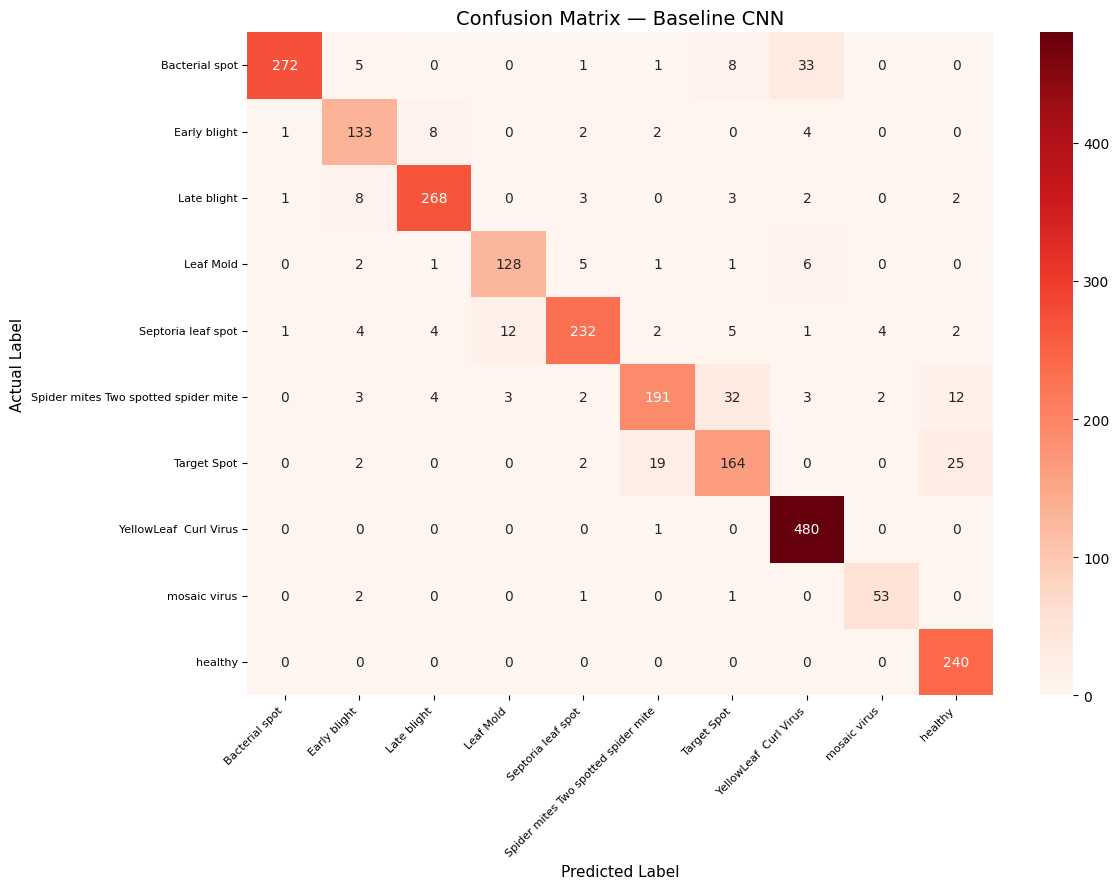

In [ ]:
#  Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 9))
sns.heatmap(cm,
            annot      = True,
            fmt        = 'd',
            cmap       = 'Reds',
            xticklabels= clean_labels,
            yticklabels= clean_labels)
plt.title("Confusion Matrix — Baseline CNN", fontsize=14)
plt.ylabel("Actual Label",    fontsize=11)
plt.xlabel("Predicted Label", fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0,  fontsize=8)
plt.tight_layout()
plt.savefig("baseline_confusion_matrix.png", dpi=150,
            bbox_inches='tight')
plt.show()

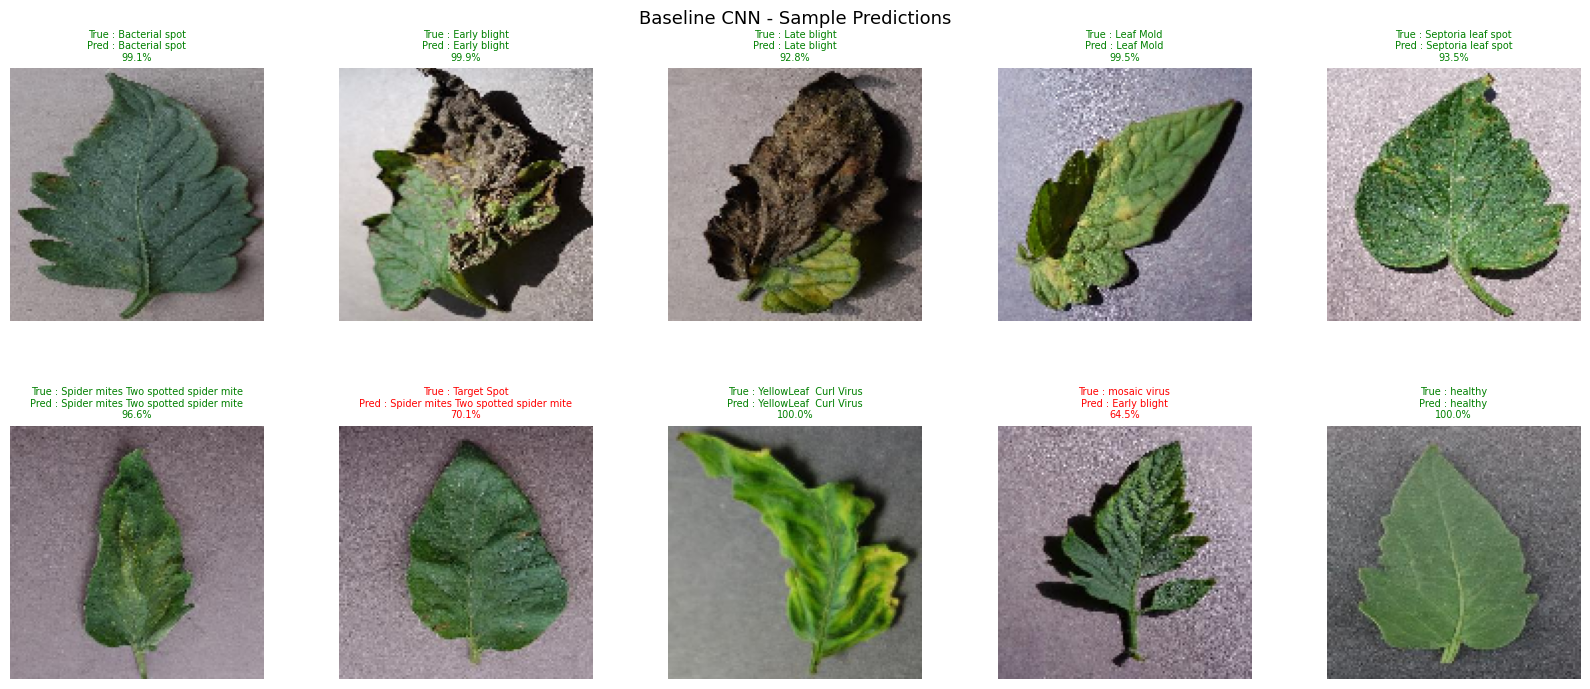

In [ ]:
# Predict on random test images and display
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

for i, cls in enumerate(class_labels):
    cls_test_path = os.path.join(TEST_PATH, cls)
    img_file      = random.choice(os.listdir(cls_test_path))
    img_path      = os.path.join(cls_test_path, img_file)

    # load and preprocess
    img     = tf.keras.preprocessing.image.load_img(
                  img_path, target_size=IMG_SIZE)
    img_arr = tf.keras.preprocessing.image.img_to_array(img)
    img_arr = img_arr / 255.0
    img_arr = np.expand_dims(img_arr, axis=0)

    # predict
    pred       = baseline_model.predict(img_arr, verbose=0)
    pred_idx   = np.argmax(pred)
    pred_label = clean_labels[pred_idx]
    confidence = pred[0][pred_idx] * 100
    true_label = cls.replace("Tomato__","").replace(
                     "Tomato_","").replace("_"," ")

    # color green if correct, red if wrong
    color = 'green' if pred_label == true_label else 'red'

    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(
        f"True : {true_label}\nPred : {pred_label}\n{confidence:.1f}%",
        fontsize=7, color=color)

plt.suptitle("Baseline CNN - Sample Predictions", fontsize=13)
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

**Deeper CNN with Regularization**

In [ ]:
def build_deeper_model(num_classes, input_shape=(128, 128, 3)):
    model = models.Sequential([

        Input(shape=input_shape),

        #  Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        #  Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        #  Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        #  Flatten
        layers.Flatten(),

        #  Fully Connected Layers
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        #  Output
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

#  Build and compile
deeper_model = build_deeper_model(NUM_CLASSES)

deeper_model.compile(
    optimizer = 'adam',
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

deeper_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 17,235,626 (65.75 MB)

 Trainable params: 17,232,938 (65.74 MB)

 Non-trainable params: 2,688 (10.50 KB)

Training Deeper Model


New Call-Backs For Deeper Model


In [ ]:
checkpoint = ModelCheckpoint(
    "best_deeper_CNN.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop_deeper = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_deeper = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)


In [ ]:
start_time = time.time()

deeper_history = deeper_model.fit(
    train_generator,
    validation_data = val_generator,
    epochs          = 25,
    class_weight    = class_weight_dict,
    callbacks       = [early_stop_deeper, reduce_lr_deeper, checkpoint],
    verbose         = 1
)

deeper_time = time.time() - start_time
print(f"Total training time : {deeper_time/60:.2f} minutes")
print(f"Baseline time was   : {baseline_time/60:.2f} minutes")

Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.3814 - loss: 2.0227
Epoch 1: val_loss improved from None to 4.58633, saving model to best_deeper_CNN.keras

Epoch 1: finished saving model to best_deeper_CNN.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 107s 247ms/step - accuracy: 0.4992 - loss: 1.5708 - val_accuracy: 0.2399 - val_loss: 4.5863 - learning_rate: 0.0010
Epoch 2/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.6321 - loss: 1.0908
Epoch 2: val_loss improved from 4.58633 to 2.46453, saving model to best_deeper_CNN.keras

Epoch 2: finished saving model to best_deeper_CNN.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 69s 198ms/step - accuracy: 0.6681 - loss: 0.9768 - val_accuracy: 0.5140 - val_loss: 2.4645 - learning_rate: 0.0010
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.7297 - loss: 0.7962
Epoch 3: val_loss improved from 2.46453 to 1.32070, saving model to best_deeper_CNN.keras

Epoch 3: finished saving model to best_deeper_CNN.keras
351/351 ━

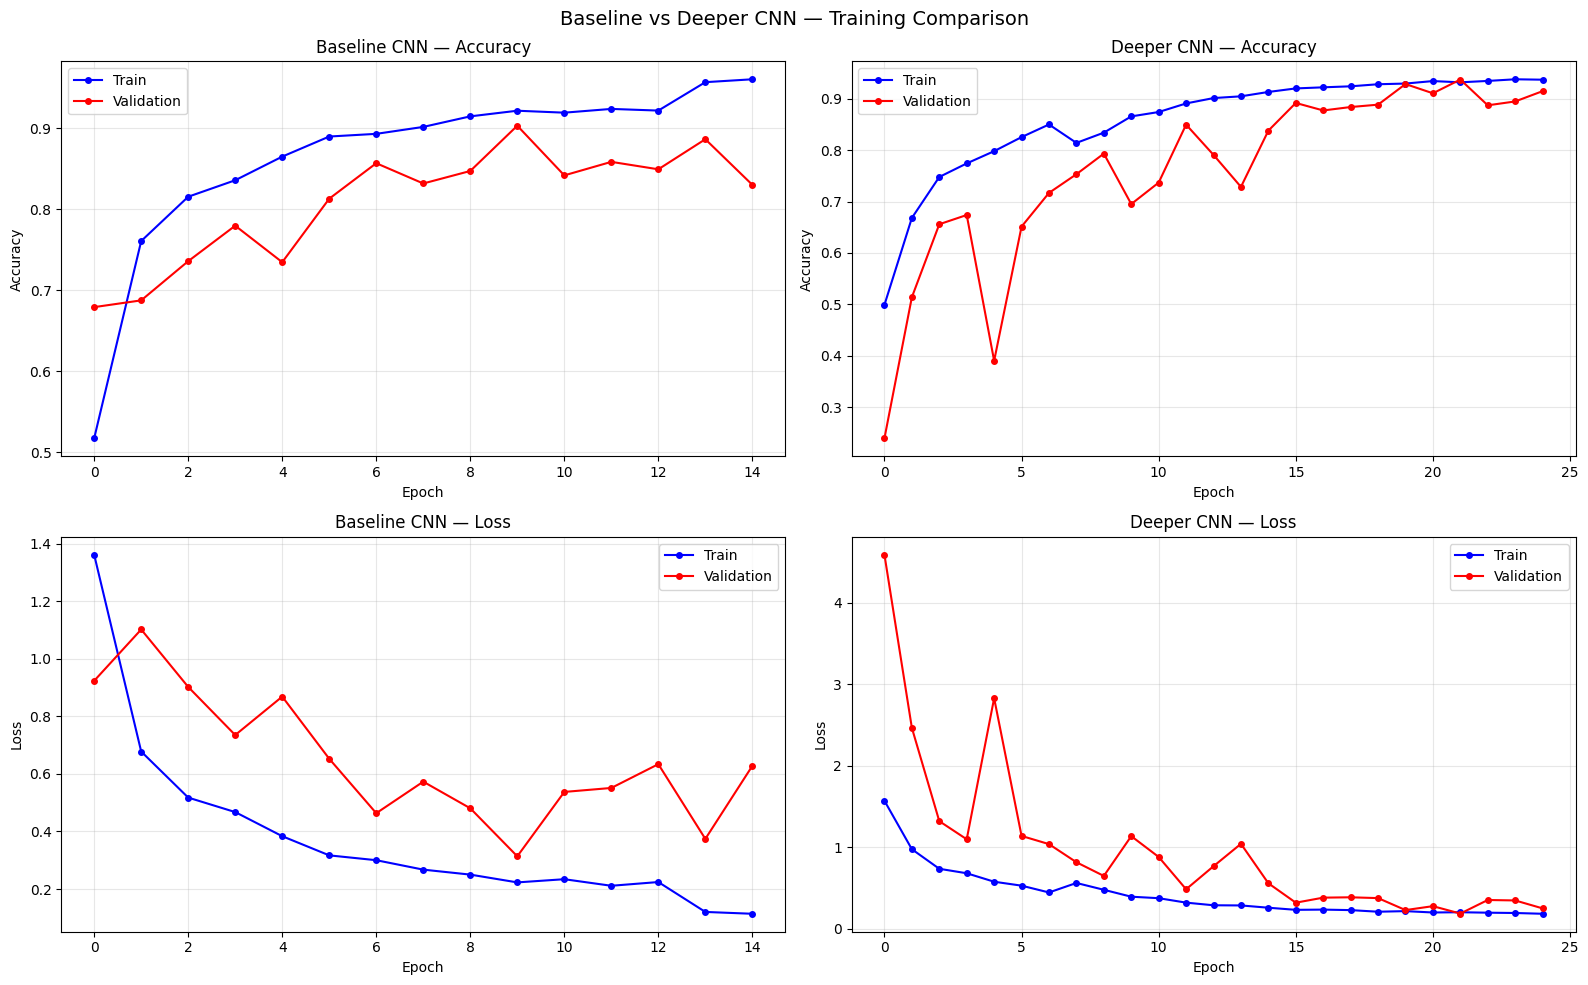

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

b_acc      = baseline_history.history['accuracy']
b_val_acc  = baseline_history.history['val_accuracy']
b_loss     = baseline_history.history['loss']
b_val_loss = baseline_history.history['val_loss']

d_acc      = deeper_history.history['accuracy']
d_val_acc  = deeper_history.history['val_accuracy']
d_loss     = deeper_history.history['loss']
d_val_loss = deeper_history.history['val_loss']

#  Baseline Accuracy
axes[0,0].plot(b_acc,     'b-o', markersize=4, label='Train')
axes[0,0].plot(b_val_acc, 'r-o', markersize=4, label='Validation')
axes[0,0].set_title('Baseline CNN — Accuracy')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

#  Deeper Accuracy
axes[0,1].plot(d_acc,     'b-o', markersize=4, label='Train')
axes[0,1].plot(d_val_acc, 'r-o', markersize=4, label='Validation')
axes[0,1].set_title('Deeper CNN — Accuracy')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

#  Baseline Loss
axes[1,0].plot(b_loss,     'b-o', markersize=4, label='Train')
axes[1,0].plot(b_val_loss, 'r-o', markersize=4, label='Validation')
axes[1,0].set_title('Baseline CNN — Loss')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Loss')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

#  Deeper Loss
axes[1,1].plot(d_loss,     'b-o', markersize=4, label='Train')
axes[1,1].plot(d_val_loss, 'r-o', markersize=4, label='Validation')
axes[1,1].set_title('Deeper CNN — Loss')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Loss')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.suptitle("Baseline vs Deeper CNN — Training Comparison",
             fontsize=14)
plt.tight_layout()
plt.savefig("baseline_vs_deeper_curves.png", dpi=150,
            bbox_inches='tight')
plt.show()

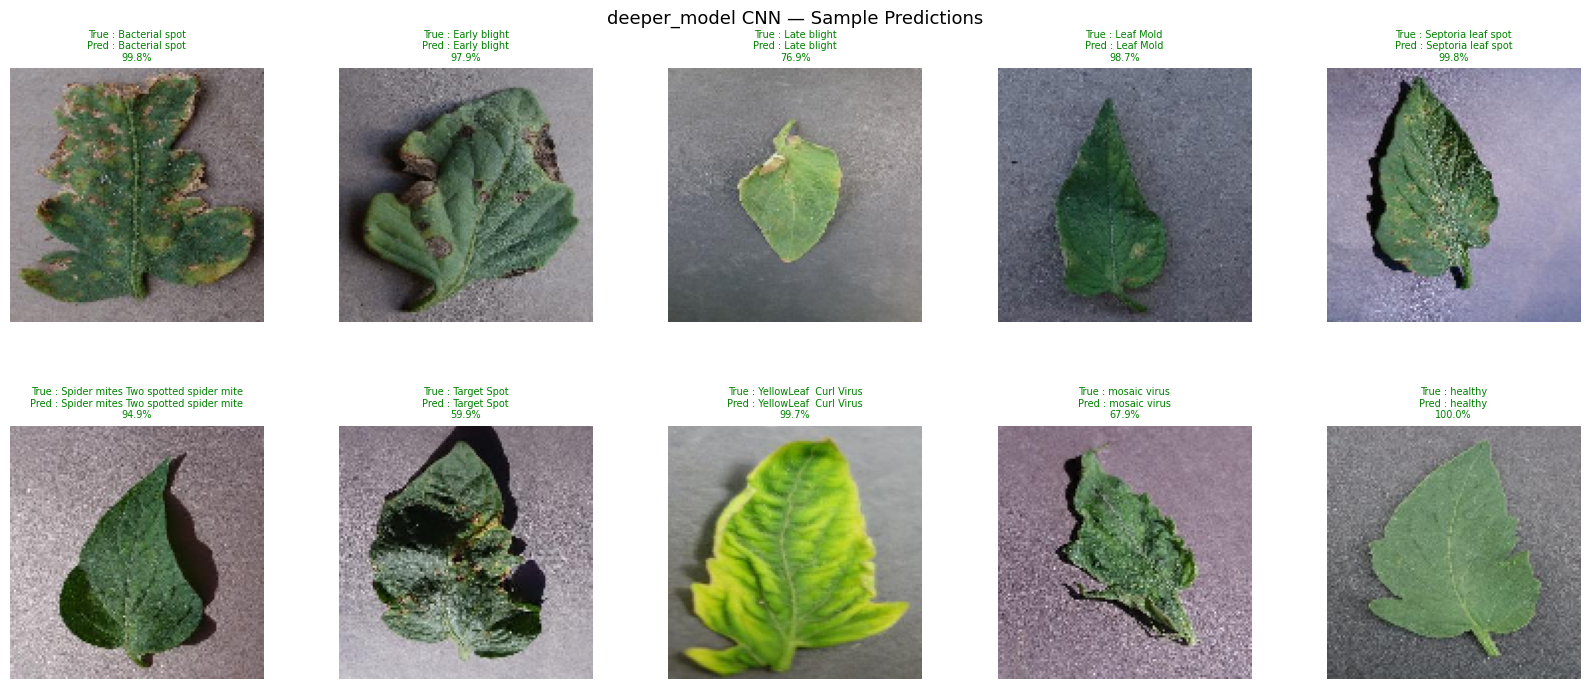

In [ ]:
# Predict on random test images and display
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

for i, cls in enumerate(class_labels):
    cls_test_path = os.path.join(TEST_PATH, cls)
    img_file      = random.choice(os.listdir(cls_test_path))
    img_path      = os.path.join(cls_test_path, img_file)

    # load and preprocess
    img     = tf.keras.preprocessing.image.load_img(
                  img_path, target_size=IMG_SIZE)
    img_arr = tf.keras.preprocessing.image.img_to_array(img)
    img_arr = img_arr / 255.0
    img_arr = np.expand_dims(img_arr, axis=0)

    # predict
    pred       = deeper_model.predict(img_arr, verbose=0)
    pred_idx   = np.argmax(pred)
    pred_label = clean_labels[pred_idx]
    confidence = pred[0][pred_idx] * 100
    true_label = cls.replace("Tomato__","").replace(
                     "Tomato_","").replace("_"," ")

    # color green if correct, red if wrong
    color = 'green' if pred_label == true_label else 'red'

    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(
        f"True : {true_label}\nPred : {pred_label}\n{confidence:.1f}%",
        fontsize=7, color=color)

plt.suptitle("deeper_model CNN — Sample Predictions", fontsize=13)
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.savefig("deeper_model_predict.png", dpi=150, bbox_inches='tight')
plt.show()

Evaluating Deeper CNN on Test Set...

76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9311 - loss: 0.1896
76/76 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step

Classification Report — Deeper CNN

                                      precision    recall  f1-score   support

                      Bacterial spot       0.97      0.97      0.97       320
                        Early blight       0.92      0.93      0.92       150
                         Late blight       0.96      0.92      0.94       287
                           Leaf Mold       0.98      0.87      0.92       144
                  Septoria leaf spot       0.91      0.97      0.94       267
Spider mites Two spotted spider mite       0.93      0.85      0.89       252
                         Target Spot       0.84      0.82      0.83       212
              YellowLeaf  Curl Virus       1.00      0.96      0.98       481
                        mosaic virus       0.98      0.95      0.96        57
                             h

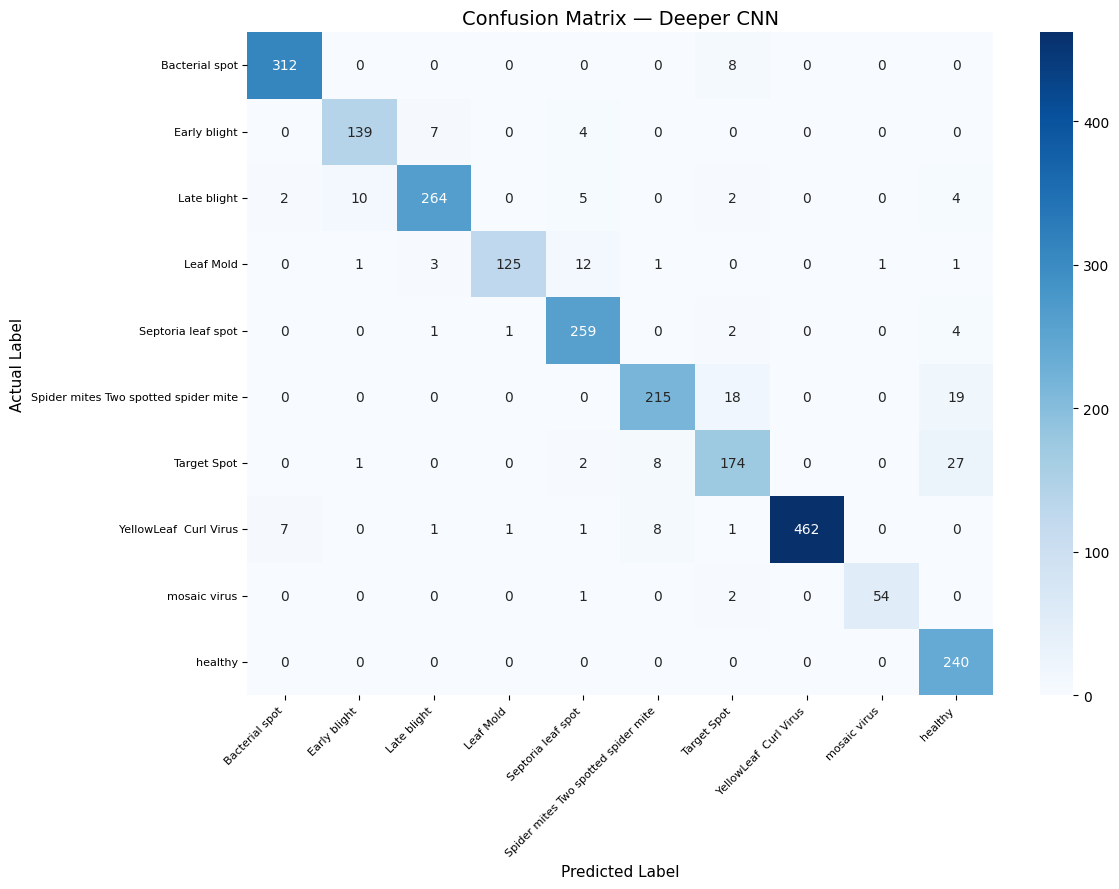


Model                  Accuracy       Loss
Baseline CNN             89.67%     0.3274
Deeper CNN               93.11%     0.1896


In [ ]:
#  Test set evaluation
print("Evaluating Deeper CNN on Test Set...\n")
test_loss_d, test_acc_d = deeper_model.evaluate(test_generator,
                                                 verbose=1)

#  Predictions
test_generator.reset()
y_pred_d = np.argmax(deeper_model.predict(
               test_generator, verbose=1), axis=1)
y_true_d = test_generator.classes

#  Classification report
print("\nClassification Report — Deeper CNN\n")
print(classification_report(y_true_d, y_pred_d,
                             target_names=clean_labels))

#  Confusion matrix
cm_d = confusion_matrix(y_true_d, y_pred_d)
plt.figure(figsize=(12, 9))
sns.heatmap(cm_d,
            annot       = True,
            fmt         = 'd',
            cmap        = 'Blues',
            xticklabels = clean_labels,
            yticklabels = clean_labels)
plt.title("Confusion Matrix — Deeper CNN", fontsize=14)
plt.ylabel("Actual Label",    fontsize=11)
plt.xlabel("Predicted Label", fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0,  fontsize=8)
plt.tight_layout()
plt.savefig("deeper_confusion_matrix.png", dpi=150,
            bbox_inches='tight')
plt.show()

#  Side by side summary
print("\n" + "="*45)
print(f"{'Model':<20} {'Accuracy':>10} {'Loss':>10}")
print("="*45)
print(f"{'Baseline CNN':<20} {test_acc*100:>9.2f}% {test_loss:>10.4f}")
print(f"{'Deeper CNN':<20} {test_acc_d*100:>9.2f}% {test_loss_d:>10.4f}")
print("="*45)

In [ ]:
checkpoint = ModelCheckpoint(
    "best_deeper_CNN.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop_deeper_SGD = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_deeper_SGD = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

In [ ]:
#  Train deeper model with SGD
deeper_sgd = build_deeper_model(NUM_CLASSES)
deeper_sgd.compile(
    optimizer = tf.keras.optimizers.SGD(learning_rate=0.01,
                                        momentum=0.9),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

print("Training Deeper CNN with SGD...\n")
start_sgd = time.time()

sgd_history = deeper_sgd.fit(
    train_generator,
    validation_data = val_generator,
    epochs          = 25,
    class_weight    = class_weight_dict,
    callbacks       = [early_stop_deeper_SGD, reduce_lr_deeper_SGD, checkpoint],
    verbose         = 1
)

sgd_time = time.time() - start_sgd
print(f"SGD Training Time: {sgd_time/60:.2f} minutes")


Training Deeper CNN with SGD...

Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.3552 - loss: 2.0888
Epoch 1: val_loss improved from None to 4.97528, saving model to best_deeper_CNN.keras

Epoch 1: finished saving model to best_deeper_CNN.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 91s 225ms/step - accuracy: 0.4342 - loss: 1.7282 - val_accuracy: 0.2244 - val_loss: 4.9753 - learning_rate: 0.0100
Epoch 2/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.5909 - loss: 1.1842
Epoch 2: val_loss improved from 4.97528 to 2.78332, saving model to best_deeper_CNN.keras

Epoch 2: finished saving model to best_deeper_CNN.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 66s 188ms/step - accuracy: 0.6181 - loss: 1.1193 - val_accuracy: 0.3588 - val_loss: 2.7833 - learning_rate: 0.0100
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.6658 - loss: 0.9699
Epoch 3: val_loss improved from 2.78332 to 1.58478, saving model to best_deeper_CNN.keras

Epoch 3: finished saving model to

In [ ]:
# Evaluate SGD model
test_generator.reset()
sgd_loss, sgd_acc = deeper_sgd.evaluate(test_generator, verbose=0)
print(f"\nSGD  - Accuracy: {sgd_acc*100:.2f}% | Loss: {sgd_loss:.4f}")
print(f"Adam - Accuracy: {test_acc_d*100:.2f}% | Loss: {test_loss_d:.4f}")


SGD  - Accuracy: 94.32% | Loss: 0.1577
Adam - Accuracy: 93.11% | Loss: 0.1896


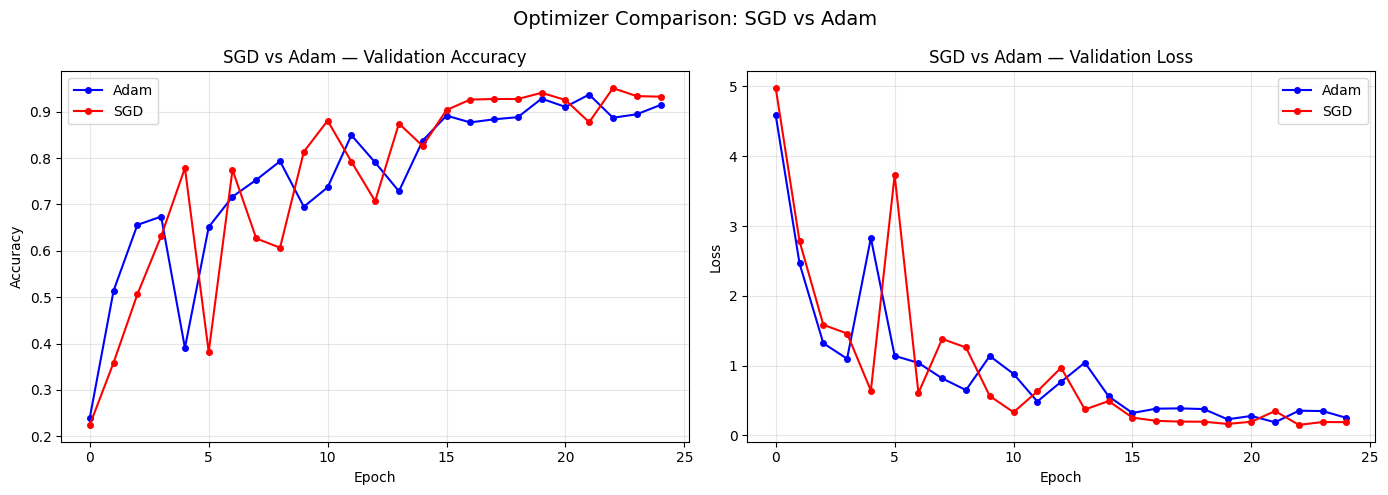

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#  Accuracy
axes[0].plot(deeper_history.history['val_accuracy'],
             'b-o', markersize=4, label='Adam')
axes[0].plot(sgd_history.history['val_accuracy'],
             'r-o', markersize=4, label='SGD')
axes[0].set_title('SGD vs Adam — Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#  Loss
axes[1].plot(deeper_history.history['val_loss'],
             'b-o', markersize=4, label='Adam')
axes[1].plot(sgd_history.history['val_loss'],
             'r-o', markersize=4, label='SGD')
axes[1].set_title('SGD vs Adam — Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Optimizer Comparison: SGD vs Adam", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
#  Build deeper model WITHOUT dropout
def build_no_dropout_model(num_classes, input_shape=(128, 128, 3)):
    model = models.Sequential([
        Input(shape=input_shape),

        # Block 1 — no dropout
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Flatten(),

        # Dense layers — no dropout
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),

        layers.Dense(num_classes, activation='softmax')
    ])
    return model



In [ ]:
#  Train
ablation_model = build_no_dropout_model(NUM_CLASSES)
ablation_model.compile(
    optimizer = 'adam',
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)


In [ ]:
ablation_history = ablation_model.fit(
    train_generator,
    validation_data = val_generator,
    epochs          = 25,
    class_weight    = class_weight_dict,
    callbacks       = [early_stop, reduce_lr],
    verbose         = 1
)


Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 90s 218ms/step - accuracy: 0.7021 - loss: 0.8839 - val_accuracy: 0.2128 - val_loss: 7.6979 - learning_rate: 0.0010
Epoch 2/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 70s 200ms/step - accuracy: 0.8152 - loss: 0.5351 - val_accuracy: 0.6170 - val_loss: 1.8641 - learning_rate: 0.0010
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.8435 - loss: 0.4492
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
351/351 ━━━━━━━━━━━━━━━━━━━━ 68s 193ms/step - accuracy: 0.8454 - loss: 0.4424 - val_accuracy: 0.4698 - val_loss: 2.4659 - learning_rate: 0.0010
Epoch 4/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 67s 190ms/step - accuracy: 0.8847 - loss: 0.3303 - val_accuracy: 0.6608 - val_loss: 1.2139 - learning_rate: 5.0000e-04
Epoch 5/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 68s 193ms/step - accuracy: 0.9030 - loss: 0.2788 - val_accuracy: 0.7509 - val_loss: 0.9194 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of 

In [ ]:
# Evaluate
test_generator.reset()
abl_loss, abl_acc = ablation_model.evaluate(test_generator, verbose=0)



In [ ]:
#  Final comparison
print("\n" + "="*50)
print(f"{'Model':<30} {'Accuracy':>10} {'Loss':>8}")
print("="*50)
print(f"{'Baseline CNN':<30} {test_acc*100:>9.2f}% {test_loss:>8.4f}")
print(f"{'Deeper CNN (Adam)':<30} {test_acc_d*100:>9.2f}% {test_loss_d:>8.4f}")
print(f"{'Deeper CNN (SGD)':<30} {sgd_acc*100:>9.2f}% {sgd_loss:>8.4f}")
print(f"{'Deeper CNN (No Dropout)':<30} {abl_acc*100:>9.2f}% {abl_loss:>8.4f}")



Model                            Accuracy     Loss
Baseline CNN                       89.67%   0.3274
Deeper CNN (Adam)                  93.11%   0.1896
Deeper CNN (SGD)                   94.32%   0.1577
Deeper CNN (No Dropout)            20.95%   7.6081
